In [85]:
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection
from coffea.nanoevents.methods import candidate

import awkward as ak
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import mplhep
import hist
mplhep.style.use(mplhep.style.CMS)
import numpy as np
import uproot as uproot
import vector;vector.register_awkward()
import matplotlib.cm as cm
import fsspec
import importlib
from helpers import *
# from plotters import *
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
# fn= "cristina_1.root:Events"
# fn= "spin0_bb_50GeV_ggF_muFilter_v15.root:Events"
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=1000000, mode='virtual').events()
gens = gen_higgs_parentage(events)

In [3]:
len(events)

1000000

In [4]:
gen_higgs = gens[gens.pdgId == 25]
higgs = gen_higgs[gen_higgs.hasFlags(['isLastCopy'])]
events["Higgs"] = higgs

gen_muons = gens[abs(gens.pdgId) == 13]
gen_muons = gen_muons[gen_muons.hasFlags(['isLastCopy'])]
gen_muons_from_higgs = gen_muons[gen_muons.fromHiggs]

muons = events.Muon
muons["higgsGenMatched"] = ~ak.is_none(muons.nearest(gen_muons_from_higgs, threshold=0.1), axis=1)

jets = events.Jet
parkingMuonMask = (muons.pt > 11) & (abs(muons.eta) < 0.9) & (muons.higgsGenMatched == True)
trigMuons = muons[(muons.triggerIdLoose) & parkingMuonMask]
jets["hasTrigMuon"] = ~ak.is_none(jets.nearest(trigMuons, threshold=0.4), axis=1)

bgens = gens[(abs(gens.pdgId) == 5)]
bgens_higgs = bgens[bgens.distinctParent.pdgId == 25]

bjets = jets[abs(jets.partonFlavour) == 5]
bjets["higgsGenMatched"] =  ~ak.is_none(bjets.nearest(bgens_higgs, threshold=0.4), axis=1)
events["bJet"] = bjets[bjets.higgsGenMatched]

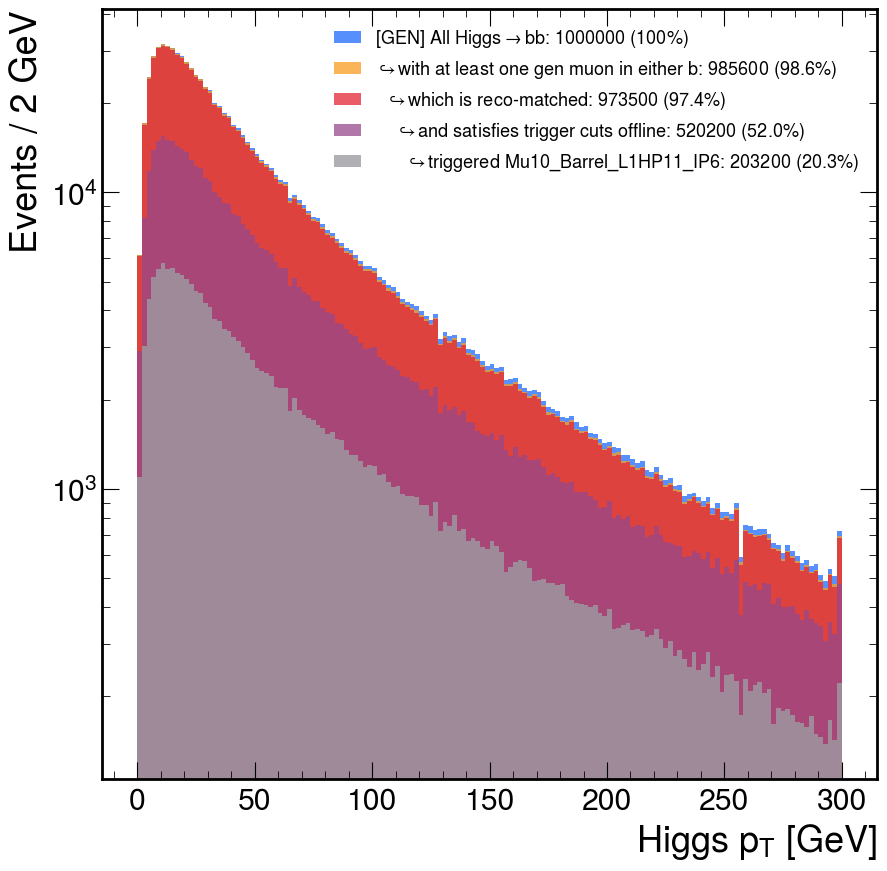

In [5]:
# all GEN Higgs
xmax  = 300

plt.hist(ak.flatten(higgs.pt), bins=150, range=(0, xmax), 
    label=f"[GEN] All Higgs$\\rightarrow bb$: {round(len(gen_higgs), -2)} (100%)")

# all GEN Higgs which spawned a muon
higgs_w_gen_muon = higgs[ak.num(gen_muons_from_higgs) > 0]
plt.hist(ak.flatten(higgs_w_gen_muon.pt), bins=150, range=(0, xmax), alpha=0.75, 
    label=f"$\hookrightarrow$with at least one gen muon in either b: {round(len(ak.flatten(higgs_w_gen_muon)),-2)} ({round(100*len(ak.flatten(higgs_w_gen_muon))/len(gen_higgs),1)}%)")

# all GEN Higgs which spawned a muon and is reco-matched
higgs_w_reco_muon = higgs[ak.num(muons[muons.higgsGenMatched]) > 0]
plt.hist(ak.flatten(higgs_w_reco_muon.pt), bins=150, range=(0, xmax), alpha=0.75, 
    label=f"$~~\hookrightarrow$which is reco-matched: {round(len(higgs_w_reco_muon),-2)} ({round(100*len(ak.flatten(higgs_w_reco_muon))/len(gen_higgs),1)}%)")

#all GEN Higgs which spawned a muon and is reco-matched and satisfies offline trigger requirements
higgs_w_reco_muon_fiducial = higgs[ak.num(muons[parkingMuonMask]) > 0]
plt.hist(ak.flatten(higgs_w_reco_muon_fiducial.pt), bins=150, range=(0, xmax), alpha=0.75,
    label=f"$~~~~\hookrightarrow$and satisfies trigger cuts offline: {round(len(higgs_w_reco_muon_fiducial), -2)} ({round(100*len(ak.flatten(higgs_w_reco_muon_fiducial))/len(gen_higgs),1)}%)")

# # all GEN Higgs which spawned a muon and is reco-matched and triggered
higgs_w_reco_muon_trigger = higgs[ak.num(muons[parkingMuonMask & (events.HLT.Mu10_Barrel_L1HP11_IP6)]) > 0]
plt.hist(ak.flatten(higgs_w_reco_muon_trigger.pt), bins=150, range=(0, xmax), alpha=0.8,
    label=f"$~~~~~~\hookrightarrow$triggered Mu10_Barrel_L1HP11_IP6: {round(len(higgs_w_reco_muon_trigger), -2)} ({round(100*len(ak.flatten(higgs_w_reco_muon_trigger))/len(gen_higgs),1)}%)")

plt.xlabel("Higgs $p_T$ [GeV]")
plt.ylabel("Events / 2 GeV")
plt.legend(fontsize=13)
plt.yscale("log")
plt.show()

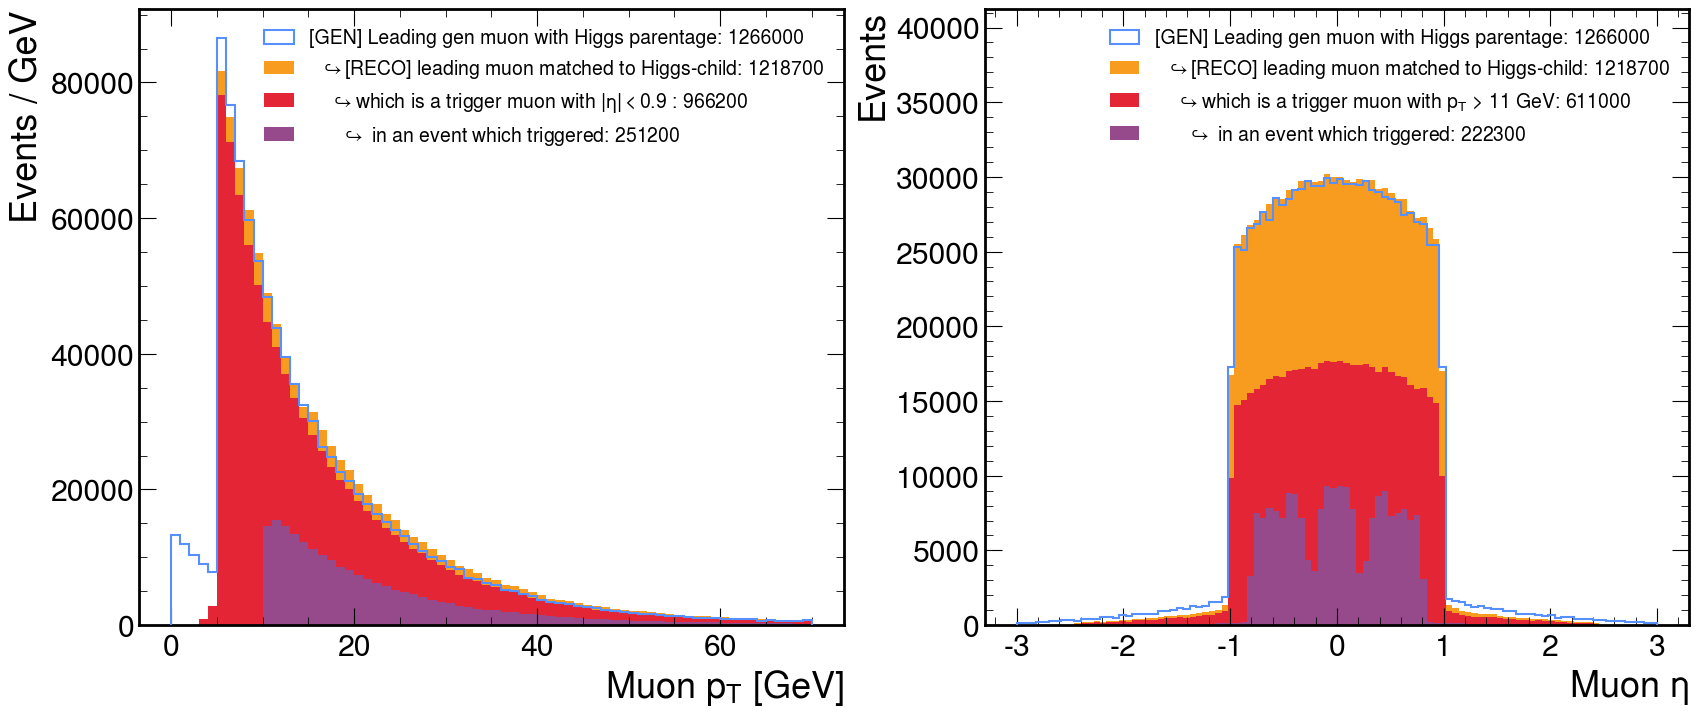

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].hist(ak.firsts(gen_muons_from_higgs.pt), histtype='step', linewidth=1.5, bins=70, range=(0,70), label=f"[GEN] Leading gen muon with Higgs parentage: {round(len(ak.flatten(gen_muons_from_higgs)), -2)}",zorder=10)
reco_mu_matched = muons[muons.higgsGenMatched]
ax[0].hist(ak.firsts(reco_mu_matched.pt), bins=70, range=(0,70), label=f"$~~\hookrightarrow$[RECO] leading muon matched to Higgs-child: {round(len(ak.flatten(reco_mu_matched)), -2)}",zorder=0)
trigger_mu_matched = muons[(muons.triggerIdLoose) & (abs(muons.eta)<0.9) & (muons.higgsGenMatched)]
ax[0].hist(ak.firsts(trigger_mu_matched.pt), bins=70, range=(0,70), label=f"$~~~~\hookrightarrow$which is a trigger muon with |$\eta | < 0.9$ : {round(len(ak.flatten(trigger_mu_matched)), -2)}",zorder=0)
trigger_mu_matched_trigger = muons[(muons.triggerIdLoose) & (abs(muons.eta)<0.9) & (muons.higgsGenMatched) & (events.HLT.Mu10_Barrel_L1HP11_IP6)]
ax[0].hist(ak.firsts(trigger_mu_matched_trigger.pt), bins=70, range=(0,70), label=f"$~~~~~~\hookrightarrow$ in an event which triggered: {round(len(ak.flatten(trigger_mu_matched_trigger)), -2)}",zorder=0)
ax[0].set_xlabel("Muon $p_T$ [GeV]")
ax[0].set_ylabel("Events / GeV")
ax[0].legend(fontsize=14)


eta_max = 3
ax[1].hist(ak.firsts(gen_muons_from_higgs.eta), histtype='step', linewidth=1.5, bins=100, range=(-eta_max, eta_max), label=f"[GEN] Leading gen muon with Higgs parentage: {round(len(ak.flatten(gen_muons_from_higgs)), -2)}",zorder=10)
reco_mu_matched = muons[muons.higgsGenMatched]
ax[1].hist(ak.firsts(reco_mu_matched.eta), bins=100, range=(-eta_max, eta_max), label=f"$~~\hookrightarrow$[RECO] leading muon matched to Higgs-child: {round(len(ak.flatten(reco_mu_matched)), -2)}",zorder=0)
trigger_mu_matched = muons[(muons.triggerIdLoose) & (muons.pt> 11) & (muons.higgsGenMatched)]
ax[1].hist(ak.firsts(trigger_mu_matched.eta), bins=100, range=(-eta_max, eta_max), label=f"$~~~~\hookrightarrow$which is a trigger muon with $p_T$ > 11 GeV: {round(len(ak.flatten(trigger_mu_matched)), -2)}",zorder=0)
trigger_mu_matched_trigger = muons[(muons.triggerIdLoose) & (muons.pt > 11) & (muons.higgsGenMatched) & (events.HLT.Mu10_Barrel_L1HP11_IP6)]
ax[1].hist(ak.firsts(trigger_mu_matched_trigger.eta),bins=100, range=(-eta_max, eta_max), label=f"$~~~~~~\hookrightarrow$ in an event which triggered: {round(len(ak.flatten(trigger_mu_matched_trigger)), -2)}",zorder=0)
ax[1].set_xlabel("Muon $\eta$")
ax[1].set_ylabel("Events")
ax[1].legend(fontsize=14)
ax[1].set_ylim(0, 1.3*max(ax[1].get_ylim()))


plt.show()

In [43]:
bjets = events.bJet
bjets.fields
print(bjets.fields)
print(bjets.pt[0] + 0)
print(bjets.E[0] + 0)
print(bjets.UParTAK4RegPtRawCorrNeutrino[0] + 0)
print(bjets.rawFactor[0] + 0)

# bjets.pt = bjets.pt*bjets.UParTAK4RegPtRawCorrNeutrino
print(bjets.pt[0])
print(bjets.E[0])

['chMultiplicity', 'nConstituents', 'nElectrons', 'nMuons', 'nSVs', 'neMultiplicity', 'electronIdx1', 'electronIdx2', 'muonIdx1', 'muonIdx2', 'svIdx1', 'svIdx2', 'hfadjacentEtaStripsSize', 'hfcentralEtaStripSize', 'PNetRegPtRawCorr', 'PNetRegPtRawCorrNeutrino', 'PNetRegPtRawRes', 'UParTAK4RegPtRawCorr', 'UParTAK4RegPtRawCorrNeutrino', 'UParTAK4RegPtRawRes', 'UParTAK4V1RegPtRawCorr', 'UParTAK4V1RegPtRawCorrNeutrino', 'UParTAK4V1RegPtRawRes', 'area', 'btagDeepFlavB', 'btagDeepFlavCvB', 'btagDeepFlavCvL', 'btagDeepFlavQG', 'btagPNetB', 'btagPNetCvB', 'btagPNetCvL', 'btagPNetCvNotB', 'btagPNetQvG', 'btagPNetTauVJet', 'btagUParTAK4B', 'btagUParTAK4CvB', 'btagUParTAK4CvL', 'btagUParTAK4CvNotB', 'btagUParTAK4Ele', 'btagUParTAK4Mu', 'btagUParTAK4QvG', 'btagUParTAK4SvCB', 'btagUParTAK4SvUDG', 'btagUParTAK4TauVJet', 'btagUParTAK4UDG', 'btagUParTAK4probb', 'btagUParTAK4probbb', 'chEmEF', 'chHEF', 'eta', 'hfEmEF', 'hfHEF', 'hfsigmaEtaEta', 'hfsigmaPhiPhi', 'mass', 'muEF', 'muonSubtrDeltaEta', 'muo

In [51]:
bjets = events.bJet
corr_bjets = ak.zip(
            {
                "pt": bjets.pt*(1-bjets.rawFactor)*bjets.UParTAK4RegPtRawCorrNeutrino,
                "eta": bjets.eta,
                "phi": bjets.phi,
                "mass": bjets.mass,
            },
            with_name="PtEtaPhiMCandidate",
            behavior=candidate.behavior,
)

print(bjets.E[0])
print(corr_bjets.E[0])

print(bjets.pt[0])
print(corr_bjets.pt[0])


[87.6, 52.1]
[93.8, 64.7]
[86.4, 51.6]
[92.6, 64.2]


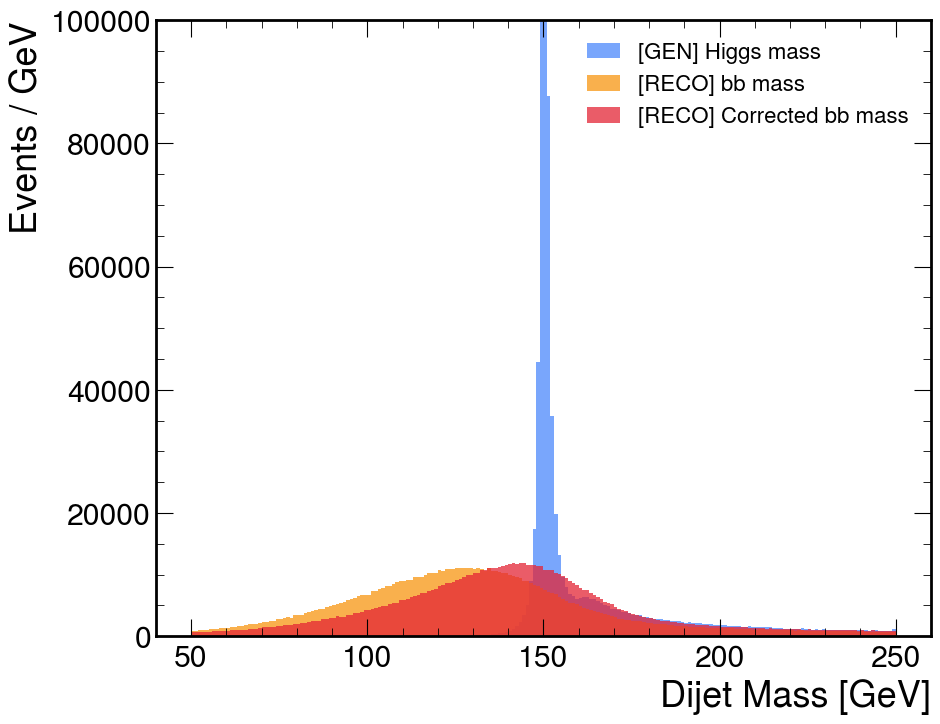

In [ ]:
# bgens = gens[(abs(gens.pdgId) == 5)]
# bgens = bgens[bgens.hasFlags(['isLastCopy'])]
bjets = events.bJet

corr_bjets = ak.zip(
            {
                # "pt": bjets.pt,
                "pt": bjets.pt*(1-bjets.rawFactor)*bjets.UParTAK4RegPtRawCorrNeutrino,
                "eta": bjets.eta,
                "phi": bjets.phi,
                "mass": bjets.mass,
                "btagUParTAK4B": bjets.btagUParTAK4B,
                "charge": bjets.charge,
            },
            with_name="PtEtaPhiMCandidate",
            behavior=candidate.behavior,
)

candidates = ak.combinations(corr_bjets, 2, fields=["b1", "b2"])
higgs_cands = candidates.b1 + candidates.b2

candidates_raw = ak.combinations(bjets, 2, fields=["b1", "b2"])
higgs_cands_raw = candidates_raw.b1 + candidates_raw.b2


higgs_masses = higgs_cands.mass



plt.figure(figsize=(10, 8))
plt.hist(ak.flatten(higgs.mass), bins=200, range=(50, 250), label=f"[GEN] Higgs mass", alpha=0.8, linewidth=1.5)
plt.hist(ak.flatten(higgs_cands_raw.mass), bins=200, range=(50, 250), label=f"[RECO] bb mass", alpha=0.8, linewidth=1.5)
plt.hist(ak.flatten(higgs_masses), bins=200, range=(50, 250), label=f"[RECO] Corrected bb mass", alpha=0.75, linewidth=1.5)
plt.xlabel("Dijet Mass [GeV]")
plt.ylabel("Events / GeV")
plt.legend(fontsize=16)
# plt.yscale("log")
plt.ylim(0, 100000)
plt.show()

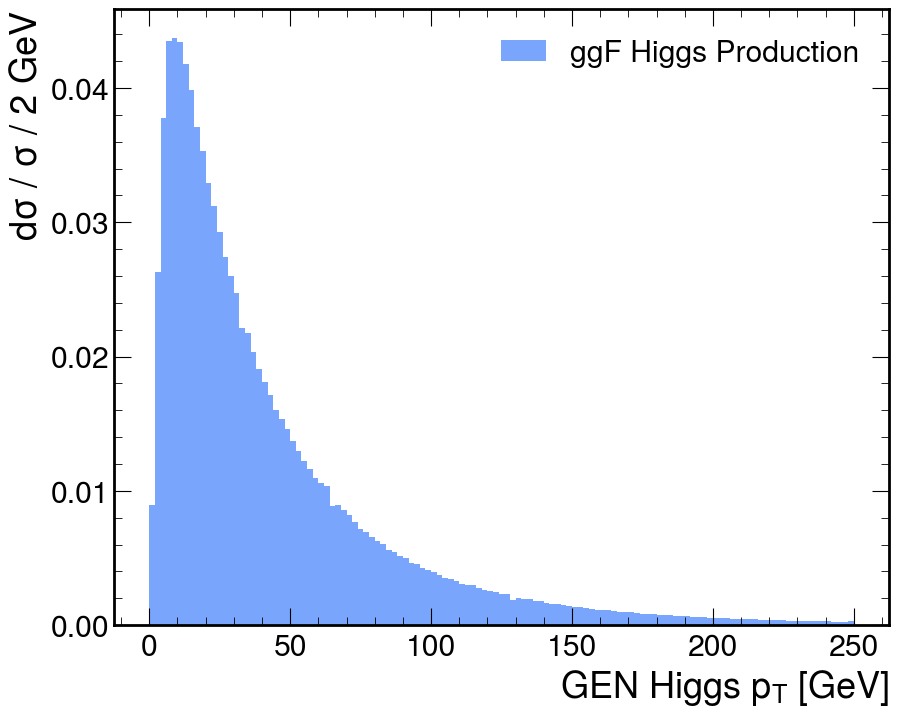

In [131]:
plt.figure(figsize=(10, 8))
plt.hist(ak.flatten(higgses_last_copy.pt), bins=125, range=(0, 250), weights=np.ones(len(ak.flatten(higgses_last_copy)))/1500000, label=f"ggF Higgs Production", alpha=0.8, linewidth=1.5)
plt.xlabel("GEN Higgs $p_T$ [GeV]")
plt.ylabel(f"$d\sigma ~/~ \sigma ~/~  2~GeV$")
plt.legend()
plt.show()

In [5]:
# gen = gen_higgs_parentage(events) # see helpers.py
# gen_higgs = gen[(gen.pdgId == 25) & (gen.status == 62)]
# gen_muons = gen[abs(gen.pdgId) == 13]
gens = events.GenPart
gens['fromHiggs'] = gens.distinctParent.pdgId == 25

jets = events.Jet
muons = events.Muon

bjets = jets[jets.btagPNetB > 0.0]
bjet_pairs = ak.combinations(bjets, 2, fields=["j1", "j2"])

higgs_cands = bjet_pairs.j1 + bjet_pairs.j2
higgs_masses = higgs_cands.mass

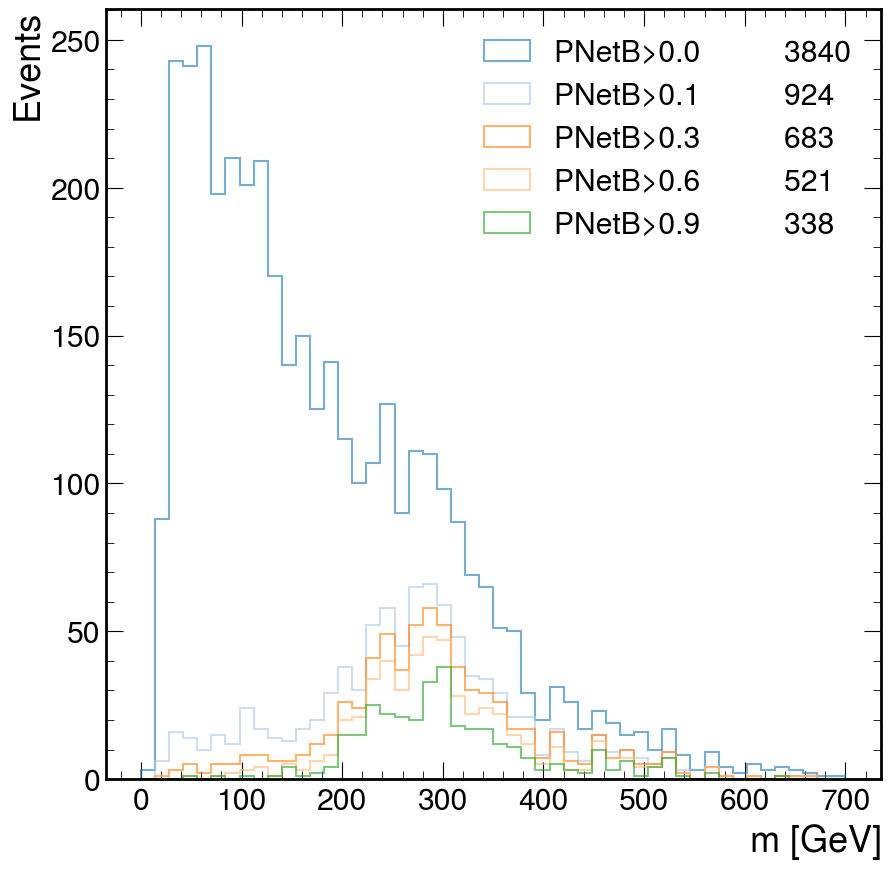

In [33]:
working_points = {
    #"btagDeepFlavB": [0.9,0.95],
    "btagPNetB": [0.0, 0.1, 0.3, 0.6, 0.9],
    # "btagUParTAK4B": [0.0, 0.1, 0.6, 0.9, 0.9]
}
c = 0#; color=plt.colormaps['tab20'](c)
for tagger, threshold in working_points.items():
    for thresh in threshold:
        bjets = jets[getattr(jets, tagger) > thresh]
        pairs = ak.combinations(bjets, 2, fields=["j1", "j2"])
        higgs_cands = pairs.j1 + pairs.j2
        m_bb = ak.flatten(higgs_cands.mass)
        plt.hist(m_bb, bins=50, range=(0, 700), histtype='step', color=plt.colormaps['tab20'](c), label=f'{tagger[4:]}>{thresh}          {len(m_bb)}', alpha=0.6, linewidth=1.5)
        c+=1
    c+3

plt.legend()
plt.xlabel("$m$ [GeV]")
#plt.yscale("log")
plt.ylabel("Events")
plt.show()

In [4]:
tagger_names = [tagger for tagger in events.Jet.fields if "btag" in tagger]
#tagger_names = [tagger for tagger in bkg_jets.fields if "btag" in tagger]
print(tagger_names)
print(len(gen))


['btagDeepFlavB', 'btagDeepFlavCvB', 'btagDeepFlavCvL', 'btagDeepFlavQG', 'btagPNetB', 'btagPNetCvB', 'btagPNetCvL', 'btagPNetCvNotB', 'btagPNetQvG', 'btagPNetTauVJet', 'btagUParTAK4B', 'btagUParTAK4CvB', 'btagUParTAK4CvL', 'btagUParTAK4CvNotB', 'btagUParTAK4QvG', 'btagUParTAK4TauVJet']
740000


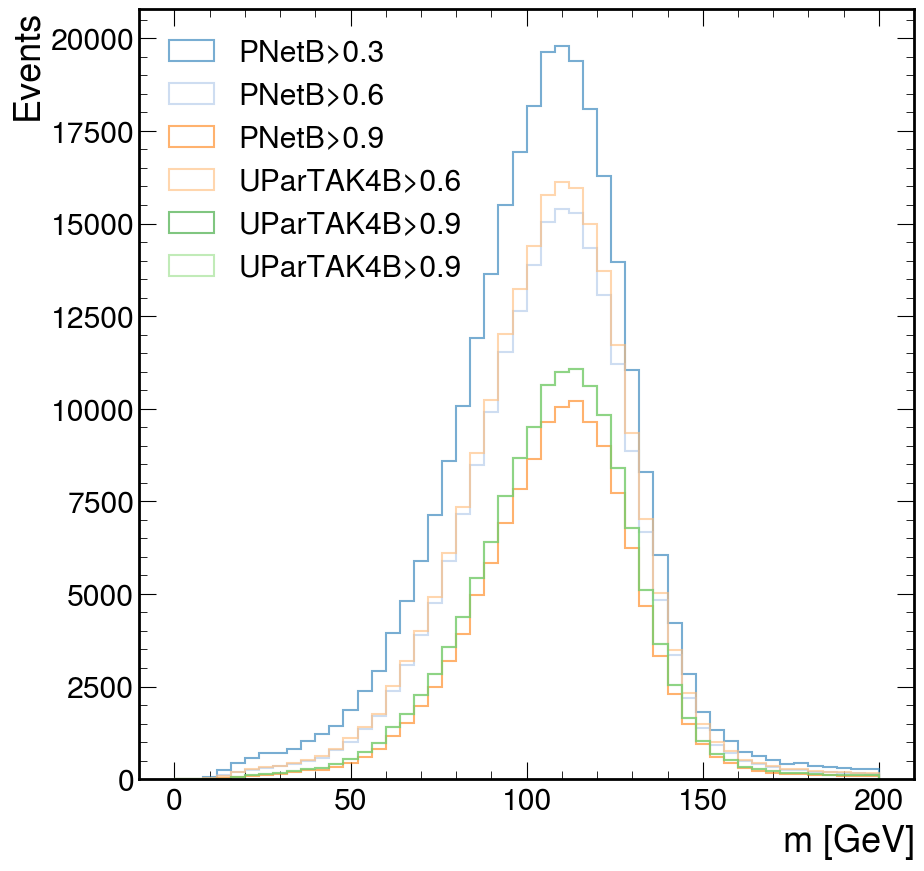

In [5]:
working_points = {
    #"btagDeepFlavB": [0.9,0.95],
    "btagPNetB": [0.3, 0.6, 0.9],
    "btagUParTAK4B": [0.6, 0.9, 0.9]
}
c = 0#; color=plt.colormaps['tab20'](c)
for tagger, threshold in working_points.items():
    for thresh in threshold:
        bjets = jets[getattr(jets, tagger) > thresh]
        pairs = ak.combinations(bjets, 2, fields=["j1", "j2"])
        higgs_cands = pairs.j1 + pairs.j2
        m_bb = ak.flatten(higgs_cands.mass)
        plt.hist(m_bb, bins=50, range=(0, 200), histtype='step', color=plt.colormaps['tab20'](c), label=f'{tagger[4:]}>{thresh}', alpha=0.6, linewidth=1.5)
        c+=1
    c+3

plt.legend()
plt.xlabel("$m$ [GeV]")
#plt.yscale("log")
plt.ylabel("Events")
plt.show()

519629
[[], [0.233], [], [], ..., [0.256, 0.135, ..., 0.22], [], [0.52, 0.393, 0.0152]]
[??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
[??, ??, ??, ??, ??, ??, ??, ??, ??, ..., ??, ??, ??, ??, ??, ??, ??, ??, ??]
['n_bparton', 'n_cparton', 'idx_jet1', 'idx_jet2', 'cc_score', 'bb_score', 'cx_score', 'bx_score', 'll_score']


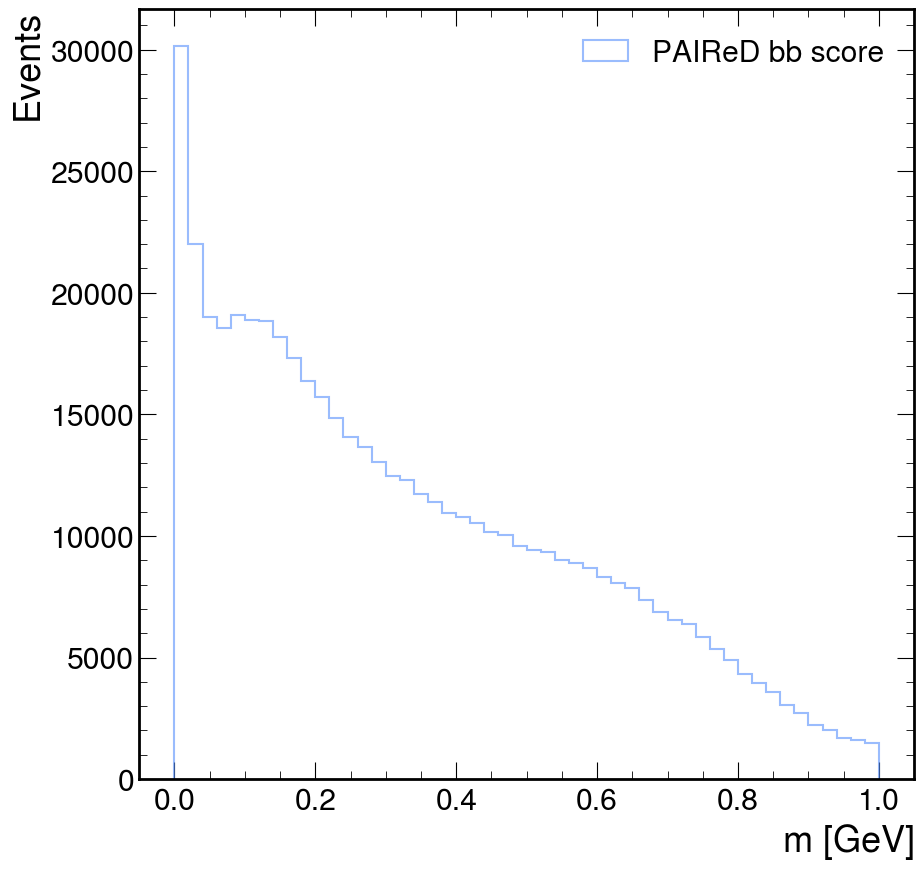

In [6]:
plt.hist(ak.max(events.PAIReDJets.bb_score, axis=1), bins=50, range=(0, 1), histtype='step', label='PAIReD bb score', alpha=0.6, linewidth=1.5)

print(ak.count(ak.max(events.PAIReDJets.bb_score, axis=1)))

print(events.PAIReDJets.bb_score)
print(ak.flatten(events.PAIReDJets.idx_jet1, axis=0))
print(ak.flatten(events.PAIReDJets.idx_jet2, axis=0))
#print(ak.count(events.Jet, axis=0))
print(events.PAIReDJets.fields)

plt.legend()
plt.xlabel("$m$ [GeV]")
#plt.yscale("log")
plt.ylabel("Events")
plt.show()

61614
61600
60967
56515
28229
14245
6919
4367
2176
1126
265


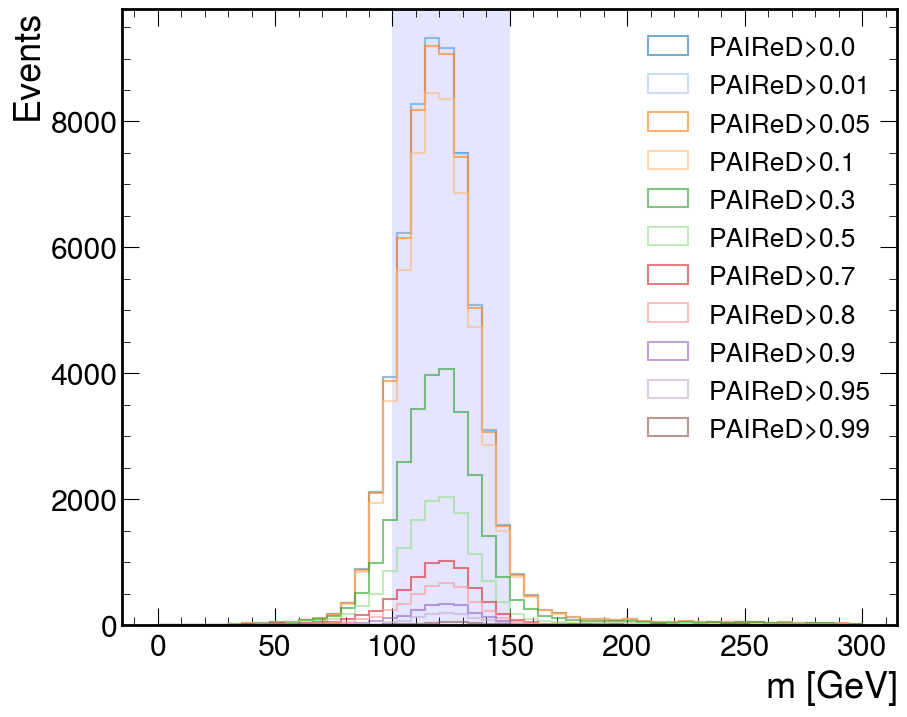

In [7]:
thresholds = {
    "PAIREd": [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
}
c = 0#; color=plt.colormaps['tab20'](c)
fig, ax = plt.subplots(figsize=(10, 8))
for thresh in thresholds["PAIREd"]:
    btag_cut = 0.9
    pt_cut = 40

    mask = events.PAIReDJets.bb_score > thresh

    jet1, jet2 = events.Jet[events.PAIReDJets.idx_jet1[mask]], events.Jet[events.PAIReDJets.idx_jet2[mask]]
    #tag_mask = (jet1.pt > 50) & (jet2.pt > 50)  
    #tag_mask = (jet1.btagDeepFlavB > btag_cut) & (jet2.btagDeepFlavB > btag_cut) 
    tag_mask = (jet1.btagDeepFlavB > btag_cut) & (jet2.btagDeepFlavB > btag_cut) & (jet1.pt > pt_cut) & (jet2.pt > pt_cut) 

    final_mass = ak.flatten((jet1[tag_mask] + jet2[tag_mask]).mass)
    print(len(final_mass))
    plt.hist(final_mass, bins=50, range=(0, 300), histtype='step', color=plt.colormaps['tab20'](c), label=f'PAIReD>{thresh}', alpha=0.6, linewidth=1.5)
    c+=1
c+3
ax.add_patch(patches.Rectangle((100, 0), 50, ax.get_ylim()[1], fill=True, color='blue', linewidth=0, alpha=0.1))

plt.legend(fontsize=19)
plt.xlabel("$m$ [GeV]")
#plt.yscale("log")
plt.ylabel("Events")
plt.show()

1413533
1344131
1101049
949854
518679
243299
85243
40808
14907
6677
1143


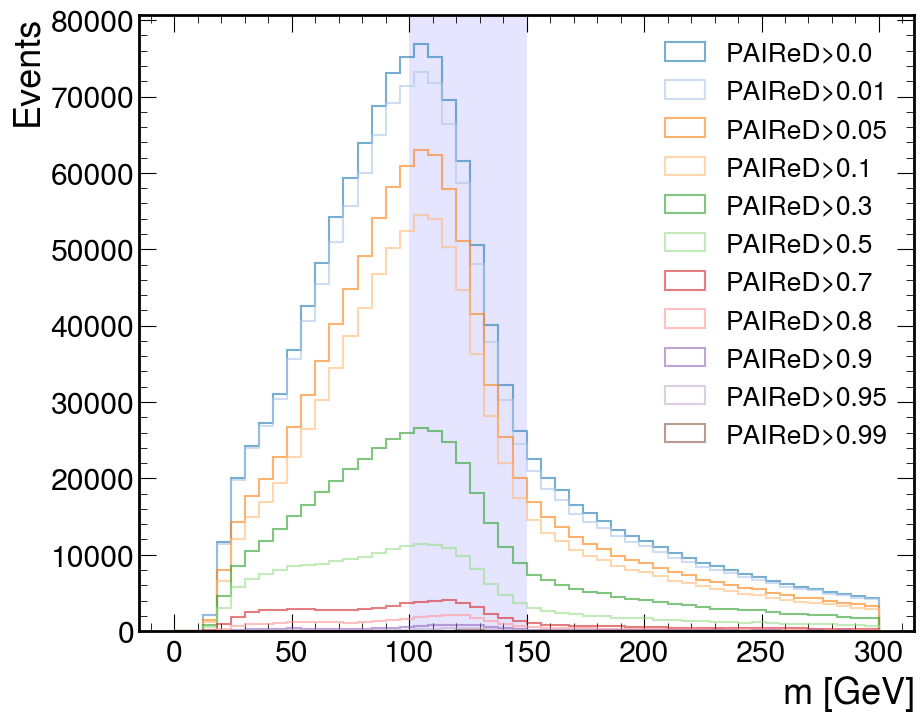

In [8]:
thresholds = {
    "PAIREd": [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
}
c = 0#; color=plt.colormaps['tab20'](c)
fig, ax = plt.subplots(figsize=(10, 8))
for thresh in thresholds["PAIREd"]:
    high_score_mask = events.PAIReDJets.bb_score > thresh

    high_score_jet1 = events.Jet[events.PAIReDJets.idx_jet1[high_score_mask]]
    high_score_jet2 = events.Jet[events.PAIReDJets.idx_jet2[high_score_mask]]
    high_score_values = events.PAIReDJets.bb_score[high_score_mask]

    high_score_mass = ak.flatten((high_score_jet1 + high_score_jet2).mass)
    print(len(high_score_mass))
    plt.hist(high_score_mass, bins=50, range=(0, 300), histtype='step', color=plt.colormaps['tab20'](c), label=f'PAIReD>{thresh}', alpha=0.6, linewidth=1.5)
    c+=1
c+3
ax.add_patch(patches.Rectangle((100, 0), 50, ax.get_ylim()[1], fill=True, color='blue', linewidth=0, alpha=0.1))

plt.legend(fontsize=19)
plt.xlabel("$m$ [GeV]")
#plt.yscale("log")
plt.ylabel("Events")
plt.show()


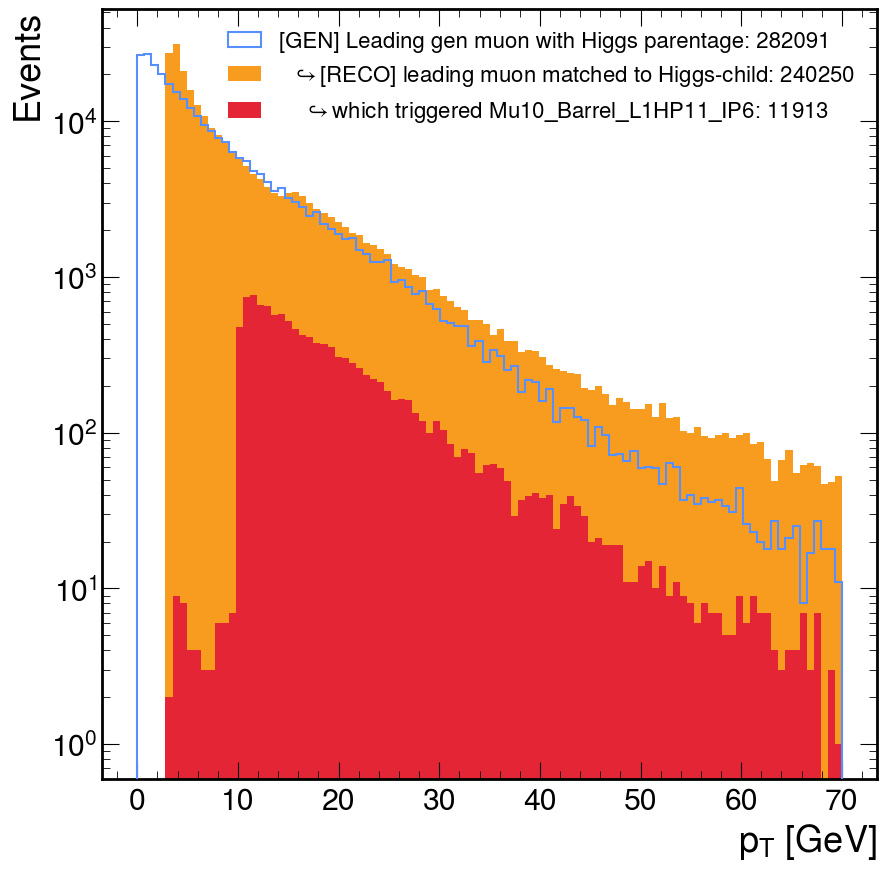

In [10]:
plt.hist(ak.firsts(gen_muons_from_higgs.pt), histtype='step', linewidth=1.5, bins=100, range=(0,70), label=f"[GEN] Leading gen muon with Higgs parentage: {ak.count(ak.firsts(gen_muons_from_higgs.pt))}",zorder=10)
plt.hist(ak.firsts(matched_muons_from_higgs.pt), bins=100, range=(0,70), label=f"$~~\hookrightarrow$[RECO] leading muon matched to Higgs-child: {ak.count(ak.firsts(matched_muons_from_higgs.pt))}",zorder=0)
plt.hist(ak.firsts(matched_muons_from_higgs[events.HLT.Mu10_Barrel_L1HP11_IP6].pt), bins=100, range=(0,70), label=f"$~~~~\hookrightarrow$which triggered Mu10_Barrel_L1HP11_IP6: {ak.count(ak.firsts(matched_muons_from_higgs[events.HLT.Mu10_Barrel_L1HP11_IP6].pt))}",zorder=0)
plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Events")
plt.legend(fontsize=16)
plt.yscale("log")
plt.show()
plt.show()

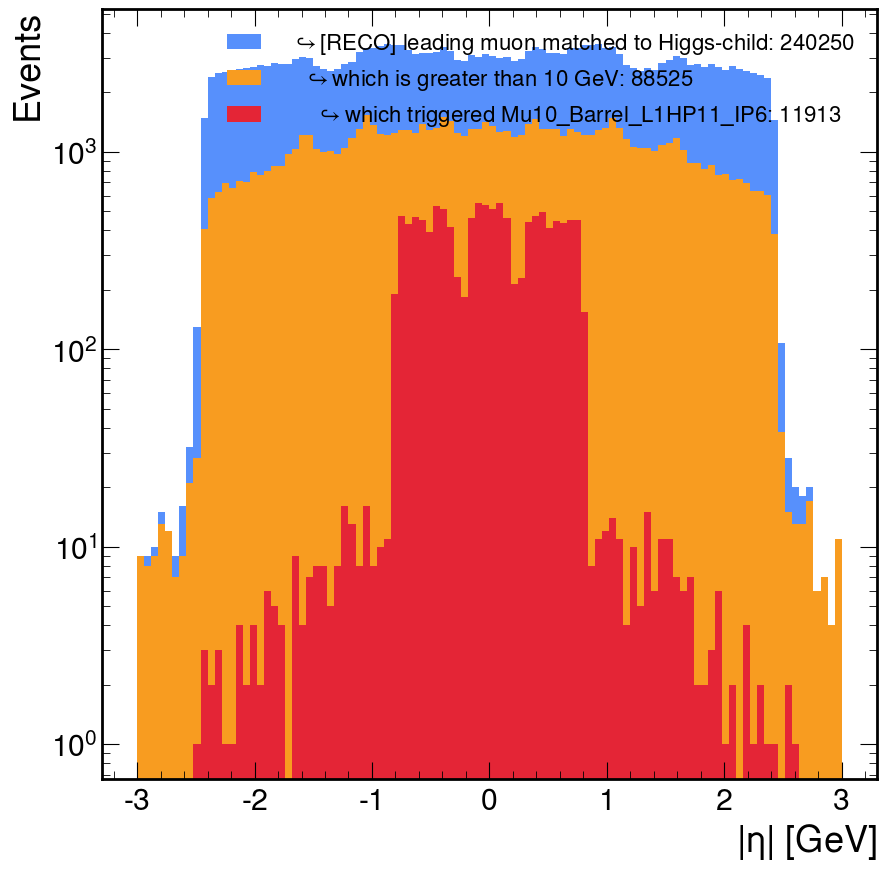

In [11]:
plt.hist(ak.firsts(matched_muons_from_higgs.eta), bins=100, range=(-3, 3), label=f"$~~\hookrightarrow$[RECO] leading muon matched to Higgs-child: {ak.count(ak.firsts(matched_muons_from_higgs.pt))}",zorder=0)
plt.hist(ak.firsts(matched_muons_from_higgs_pt10.eta), bins=100, range=(-3,3), label=f"$~~~~\hookrightarrow$which is greater than 10 GeV: {ak.count(ak.firsts(matched_muons_from_higgs_pt10.pt))}",zorder=0)
plt.hist(ak.firsts(matched_muons_from_higgs[events.HLT.Mu10_Barrel_L1HP11_IP6].eta), bins=100, range=(-3,3), label=f"$~~~~~~\hookrightarrow$which triggered Mu10_Barrel_L1HP11_IP6: {ak.count(ak.firsts(matched_muons_from_higgs[events.HLT.Mu10_Barrel_L1HP11_IP6].pt))}",zorder=0)
plt.xlabel("$|\eta|$ [GeV]")
plt.ylabel("Events")
plt.legend(fontsize=16)
plt.yscale("log")
plt.show()
plt.show()


In [12]:
gen_b_quark_from_higgs = gen[(abs(gen.pdgId) == 5) & (gen.hasFlags(['isLastCopy']))]
len(ak.flatten(gen_b_quark_from_higgs[gen_b_quark_from_higgs.eta < 2.4]))

1386248

In [13]:
trigger_names = [name for name in events.HLT.fields if "Mu10" in name]
for name in trigger_names:
    print(name)
trigger_mask = events.HLT.DoubleIsoMu20_eta2p1

Mu10_Barrel_L1HP11_IP6
L2Mu10_NoVertex_NoBPTX3BX
L2Mu10_NoVertex_NoBPTX
CascadeMu100
HighPtTkMu100
Mu3er1p5_PFJet100er2p5_PFMETNoMu100_PFMHTNoMu100_IDTight
DoubleL2Mu10NoVtx_2Cha_VetoL3Mu0DxyMax1cm
L2Mu10NoVtx_2Cha
L2Mu10NoVtx_2Cha_VetoL3Mu0DxyMax1cm
L3Mu10NoVtx
L3Mu10NoVtx_DxyMin0p01cm
DoubleL2Mu10NoVtx_2Cha_CosmicSeed_VetoL3Mu0DxyMax1cm
L2Mu10NoVtx_2Cha_CosmicSeed
L2Mu10NoVtx_2Cha_CosmicSeed_VetoL3Mu0DxyMax1cm
L3dTksMu10_NoVtx_DxyMin0p01cm


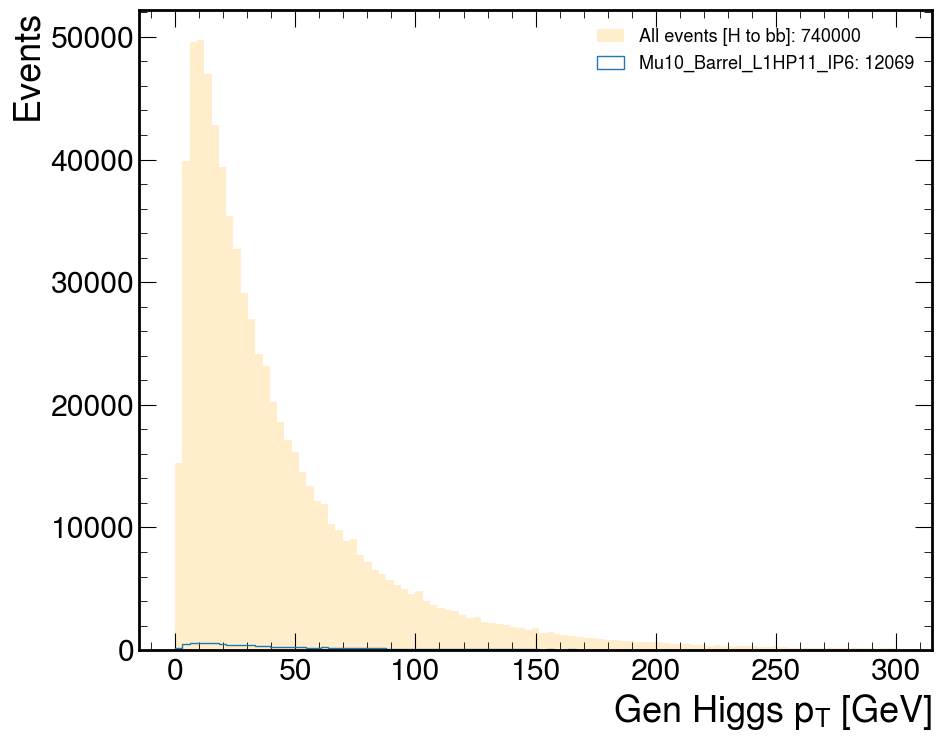

In [14]:
triggers = events.HLT.fields 
counts = {
    name: ak.sum(getattr(events.HLT, name))
    for name in triggers
}

sort = sorted(counts.items(), key=lambda x: x[1], reverse=True)
#best_triggers = [name for name, _ in sort[11:27]]
best_triggers = ["Mu10_Barrel_L1HP11_IP6"]
# print("Top triggers:")
# for name in best_triggers:
#     print(f"{name}: {counts[name]}")

bins = np.linspace(0, 300, 100)
plt.figure(figsize=(10, 8))
plt.hist(gen_higgs.pt, bins=bins, histtype='stepfilled', alpha=0.2, color='orange', label=f"All events [H to bb]: {len(events)} ")
for i, name in enumerate(best_triggers):
    mask = getattr(events.HLT, name)
    pt_pass = gen_higgs[mask].pt
    plt.hist(pt_pass, bins=bins, histtype='step', label=f"{name}: {counts[name]}", color=plt.colormaps['tab20'](i))


plt.xlabel("Gen Higgs $p_T$ [GeV]")
plt.ylabel("Events")
plt.legend(fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
bkg_files = ["muEnrichedQCD_2024_PAIReD/QCD_PT-20to30_MuEnrichedPt5_TuneCP5_13p6TeV_pythia8/MuRichQCD_20_30.root:Events",
             "muEnrichedQCD_2024_PAIReD/QCD_PT-30to50_MuEnrichedPt5_TuneCP5_13p6TeV_pythia8/MuRichQCD_30_50.root:Events",
             "muEnrichedQCD_2024_PAIReD/QCD_PT-50to80_MuEnrichedPt5_TuneCP5_13p6TeV_pythia8/MuRichQCD_50_80.root:Events",
             "muEnrichedQCD_2024_PAIReD/QCD_PT-80to120_MuEnrichedPt5_TuneCP5_13p6TeV_pythia8/MuRichQCD_80_120.root:Events",
             "muEnrichedQCD_2024_PAIReD/QCD_PT-120to170_MuEnrichedPt5_TuneCP5_13p6TeV_pythia8/MuRichQCD_120_170.root:Events"]

bkg_file = "Run3Summer24NanoAODv12_PAIReD_bbarQCD.root:Events"

# Create a dictionary mapping each file to its tree path
#background = [NanoEventsFactory.from_root(bkg_file, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None).events() for bkg_file in bkg_files]
background = NanoEventsFactory.from_root(bkg_file, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None).events()


In [21]:
PF_list = [name for name in events.fields if "PAIReD" in name]
for name in PF_list:
    print(name)

print(PF_list)
print(events.PAIReDJets.fields)

PAIReDJets
['PAIReDJets']
['n_bparton', 'n_cparton', 'idx_jet1', 'idx_jet2', 'cc_score', 'bb_score', 'cx_score', 'bx_score', 'll_score']


In [22]:
trigger_names = [name for name in background.Jet.fields if "tag" in name]
for name in trigger_names:
    print(name)

btagDeepFlavB
btagDeepFlavCvB
btagDeepFlavCvL
btagDeepFlavQG
btagPNetB
btagPNetCvB
btagPNetCvL
btagPNetCvNotB
btagPNetQvG
btagPNetTauVJet
btagUParTAK4B
btagUParTAK4CvB
btagUParTAK4CvL
btagUParTAK4CvNotB
btagUParTAK4QvG
btagUParTAK4TauVJet


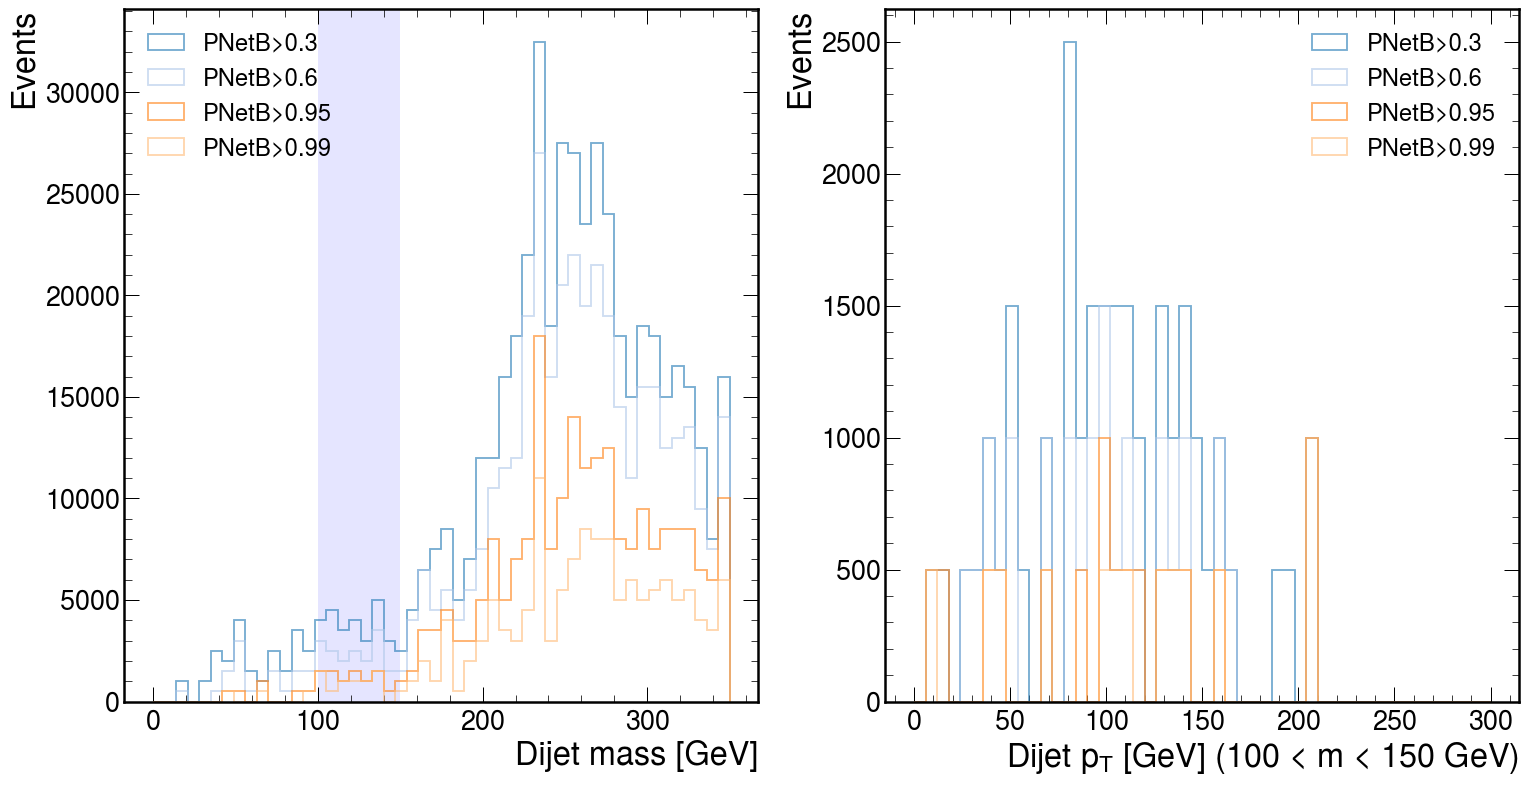

In [23]:
working_points = {
    #"btagDeepFlavB": [0.9,0.95],
    "btagPNetB": [0.3, 0.6, 0.95, 0.99],
    #"btagUParTAK4B": [0.0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
}
c = 0#; color=plt.colormaps['tab20'](c)
bkg_jets = background.Jet
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(20, 10)
fig.set_dpi(90)
for tagger, threshold in working_points.items():
    for thresh in threshold:
        bkg_jets_btag_tag = bkg_jets[getattr(bkg_jets, tagger) > thresh]
        bkg_jet_pairs_tag = ak.combinations(bkg_jets_btag_tag, 2, fields=["j1", "j2"])
        pair_jj = bkg_jet_pairs_tag.j1 + bkg_jet_pairs_tag.j2
        ax1.hist(ak.flatten(pair_jj.mass), bins=50, range=(0, 350), histtype='step', 
                 label=f'{tagger[4:]}>{thresh}', alpha=0.6, linewidth=1.5, 
                 color=plt.colormaps['tab20'](c)
                 )
        ax2.hist(ak.flatten(pair_jj.pt[(pair_jj.mass>100) & (pair_jj.mass<150)]),
                 bins=50, range=(0, 300), histtype='step', 
                 label=f'{tagger[4:]}>{thresh}', alpha=0.6, 
                 linewidth=1.5, color=plt.colormaps['tab20'](c)
                 )
        c+=1

ax1.add_patch(patches.Rectangle((100, 0), 50, ax1.get_ylim()[1], fill=True, color='blue', linewidth=0, alpha=0.1))
ax2.set_xlabel("Dijet $p_T$ [GeV] (100 < m < 150 GeV)")
ax1.set_xlabel("Dijet mass [GeV]")
ax1.set_ylabel("Events"); ax1.legend(fontsize=19)
ax2.set_ylabel("Events"); ax2.legend(fontsize=19)
plt.show()

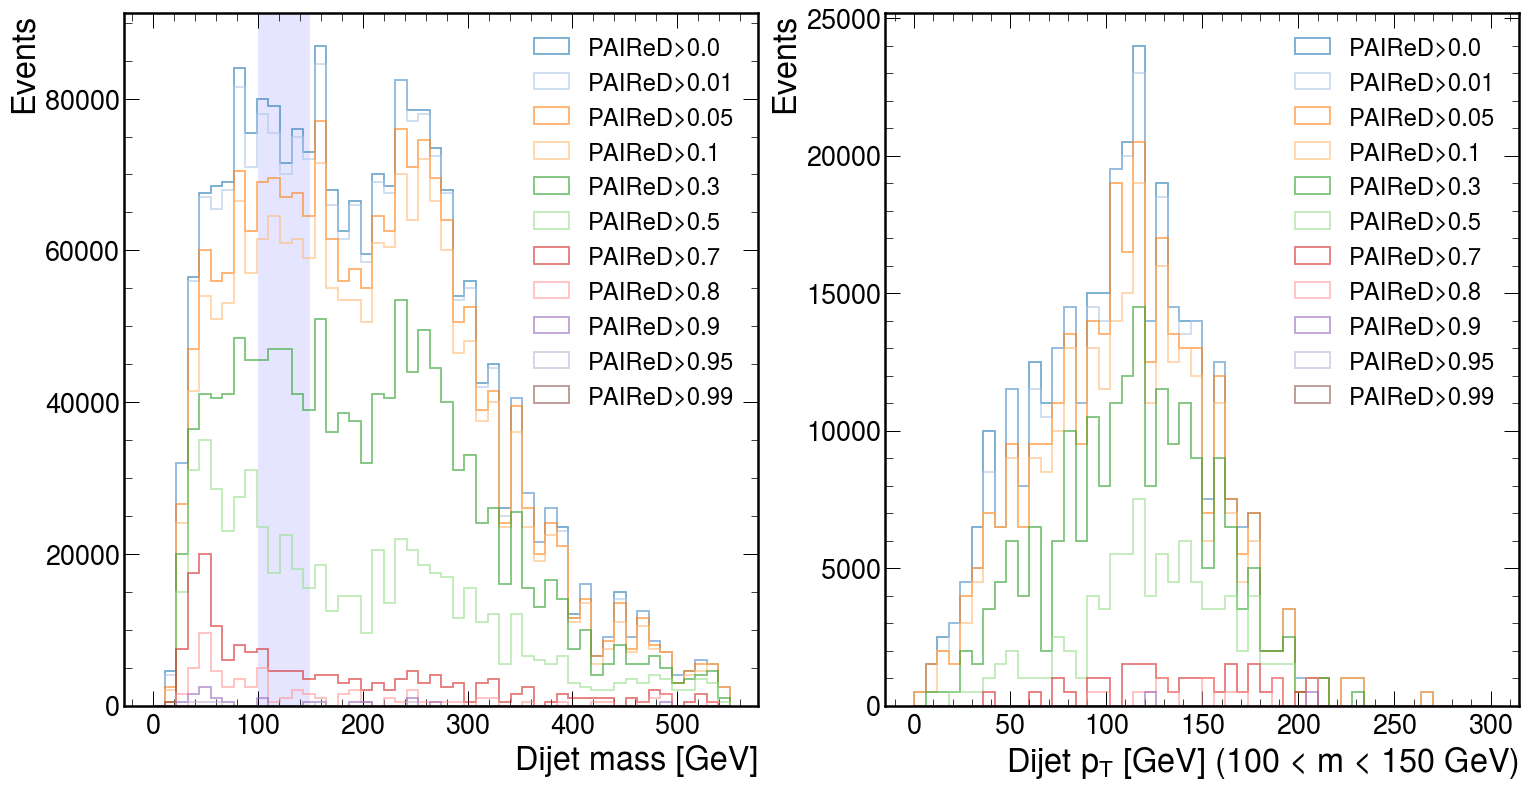

In [30]:
thresholds = {
    "PAIREd": [0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
}
c = 0#; color=plt.colormaps['tab20'](c)
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(20, 10)
fig.set_dpi(90)
for thresh in thresholds["PAIREd"]:
    high_score_mask = background.PAIReDJets.bb_score > thresh

    high_score_jet1 = background.Jet[background.PAIReDJets.idx_jet1[high_score_mask]]
    high_score_jet2 = background.Jet[background.PAIReDJets.idx_jet2[high_score_mask]]
    high_score_values = background.PAIReDJets.bb_score[high_score_mask]

    high_score_dijet = high_score_jet1 + high_score_jet2
    ax1.hist(ak.flatten(high_score_dijet.mass), bins=50, range=(0, 550), histtype='step', 
             label=f'PAIReD>{thresh}', alpha=0.6, linewidth=1.5, 
             color=plt.colormaps['tab20'](c)
             )
    ax2.hist(ak.flatten(high_score_dijet.pt[(high_score_dijet.mass>100) & (high_score_dijet.mass<150)]),
             bins=50, range=(0, 300), histtype='step', 
             label=f'PAIReD>{thresh}', alpha=0.6, 
             linewidth=1.5, color=plt.colormaps['tab20'](c)
             )    
    c+=1
c+3
ax1.add_patch(patches.Rectangle((100, 0), 50, ax1.get_ylim()[1], fill=True, color='blue', linewidth=0, alpha=0.1))
ax2.set_xlabel("Dijet $p_T$ [GeV] (100 < m < 150 GeV)")
ax1.set_xlabel("Dijet mass [GeV]")
ax1.set_ylabel("Events"); ax1.legend(fontsize=19)
ax2.set_ylabel("Events"); ax2.legend(fontsize=19)
plt.show()

In [31]:
for i in [0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]: 
    cuts = {
        'j_pt_min': 20,
        'j_eta_max': 2.4,
        'p_deltaR_min': 0.4,
        'j_btagPNetB_min': 0.6783,
        'p_PAIReDbb_min': i,
    }
    result = get_yields(events, background, cuts)
    print(result[0]/np.sqrt(result[1]))   


975.8021768370883
925.5110221785114
526.1105928246958
346.8290504300674
186.49953083050906
134.54421020616235
122.40236108833848


/tmp/ipykernel_31/4146705636.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  print(result[0]/np.sqrt(result[1]))


inf
inf


In [ ]:
#cuts = {'p_PAIReDbb_min': 0.10}
#result = get_yields(events, background, cuts, mass_window=[0, np.inf])
#print(result[1]) # outputs 27634.0
#print(ak.sum(ak.any(background.PAIReDJets.bb_score > 0.10, axis=1))) # outputs 64329
print(total_background_yields)

[[5378. 3683. 2298. 1143.  447.  139.]
 [4534. 3209. 2037. 1041.  408.  130.]
 [3945. 2860. 1841.  943.  375.  124.]]


Processing background sample 1/5


/srv/helpers.py:128: RuntimeWarning: divide by zero encountered in scalar divide
  significances[n_idx] = min(signal_yield / np.sqrt(background_yield), signal_yield)


[[48648.64864865 45945.94594595 40540.54054054 35135.13513514
  24324.32432432 24324.32432432 16216.21621622 10810.81081081
   5405.40540541  5405.40540541  2702.7027027   2702.7027027
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.        ]
 [18918.91891892 16216.21621622 13513.51351351 13513.51351351
   8108.10810811  8108.10810811  5405.40540541  5405.40540541
   2702.7027027   2702.7027027   2702.7027027   2702.7027027
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.        ]
 [13513.51351351 10810.81081081 10810.81081081 10810.81081081
   8108.10810811  8108.10810811  5405.40540541  5405.40540541
   2702.7027027   2702.7027027   2702.7027027   2702.7027027
      0.             0.             0.             0.
      0.             0.             0.             0.
      0.        ]
 [10810.81081081  8108.10810811  8108.10810811  8108.10810811
   81

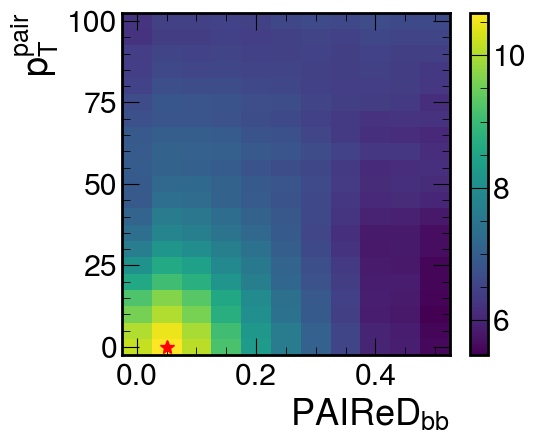

In [ ]:
bgkweights = [0.00037, 0.00068, 0.0025, 0.01051, 0.04352]

# Define the scan parameters
scan_params = {
    'j_btagDeepFlavB_min': [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    'p_PAIReDbb_min': [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35],
    'j_pt_min': [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
}

flat_cuts = {
    'j_eta_max': 2.4,
    'j_btagDeepFlavB_min': 0.5,
    'p_pt_min': 40
}
scan_results = {}
total_background_yields = 0
for i, bkg_sample in enumerate(background):
    print(f"Processing background sample {i+1}/{len(background)}")
    scan_result = scan_parameters(events, bkg_sample, scan_params, flat_cuts)
    total_background_yields += scan_result['background_yields'] * (1/bgkweights[i])
    print(total_background_yields)
    

# Create the final result dictionary
scan_result["background_yields"] = total_background_yields
scan_result["significances"] = scan_result["signal_yields"] / np.sqrt(total_background_yields)

# Plot results
fig = plot_parameter_combinations(scan_result)
plt.show()

/srv/helpers.py:128: RuntimeWarning: divide by zero encountered in scalar divide
  # opt_window, max_sig = find_optimal_mass_window(signal_mass, background_mass)


3454.277811641675
[[2050.0019606  2082.45010745 1823.23686521 1191.07360534  851.
   484.          219.          106.           22.        ]
 [2436.99796037 2588.83860705 1923.91288784 1404.31406744  819.
   472.          214.          103.           22.        ]
 [2492.13568384 2600.83685833 1851.91149897 1357.64501988  794.
   457.          208.          101.           21.        ]
 [2933.64498534 2939.089336   1787.06552762 1315.92571979  772.
   446.          203.           97.           21.        ]
 [3158.64599156 3277.41727584 1925.         1274.2064197   757.
   438.          199.           97.           21.        ]
 [3244.82500078 3454.27781164 1857.5        1236.7297603   740.
   428.          198.           96.           21.        ]
 [3104.6001813  3316.53602423 1785.         1192.88913986  707.
   409.          189.           93.           21.        ]
 [2960.59571708 3167.61389693 1707.5        1141.97745162  678.
   393.          183.           89.           20.        

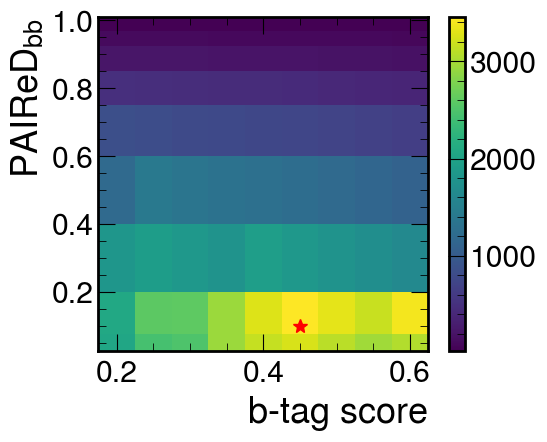

In [ ]:
scan_result = scan_parameters(events, background[0], 
                {#'j_pt_min': [20, 22.5, 25, 27.5, 30, 32.5, 35, 37.5, 40],
                #'j_btagUParTAK4B_min': [0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01],
                'j_btagDeepFlavB_min': [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6],
                #'p_deltaR_min': [0.1, 0.2, 0.3, 0.4, 0.5 ],
                #'p_pt_min': [0.0, 10.0, 20.0, 30.0, 40.0]
                'p_PAIReDbb_min': [0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
                 },
                #flat_cuts={'j_eta_max': 2.4}
                flat_cuts={'j_pt_min': 20,
                'j_eta_max': 2.4,
                'p_deltaR_min': 0.4}
)

best_idx = np.unravel_index(np.argmax(scan_result['significances']), scan_result['significances'].shape)
best_values = {name: values[i] for name, values, i in zip(scan_result['parameters'], scan_result['values'], best_idx)}
best_sig = scan_result['significances'][best_idx]
print(best_sig)
print(scan_result['significances'])

fig = plot_parameter_combinations(scan_result)
plt.show()

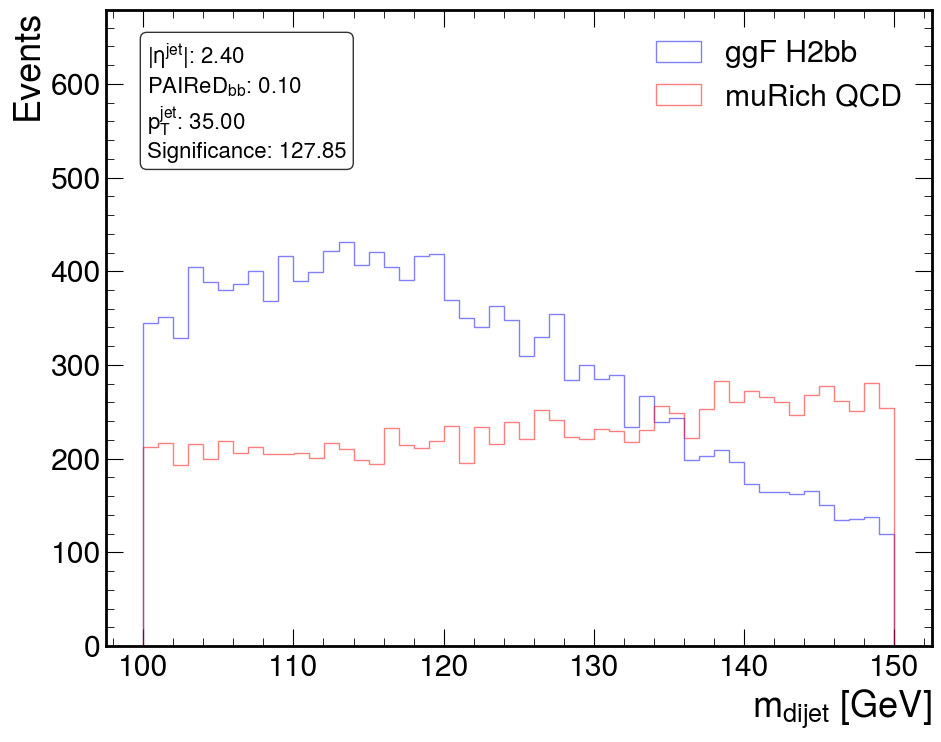

In [ ]:
fig2 = plot_mass_distribution(scan_result)

In [ ]:
hasee = ak.is_none(ak.with_name(eepair, "LorentzVector").mass)
haspho = ak.num(events.Photon) > 0
hastrigger = events.HLT.DoubleEle4_eta1p22_mMax6

print(ak.sum(hasee & hastrigger) / ak.sum(hastrigger))
print(ak.sum(hasee & haspho & hastrigger) / ak.sum(hastrigger))

In [298]:
%history

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
import matplotlib.pyplot as plt
import mplhep
mplhep.style.use(mplhep.style.CMS)
import numpy as np
import uproot as uproot
import vector;vector.register_awkward()
import matplotlib.cm as cm
redir = "root://cmsxrootd.fnal.gov/"
#fn= "higgsToCC_Summer2023_nanov14v2.root:Events"
#fn= "ggF_hBB_sum24_nano_2.root:Events"
fn= "Run3Summer24NanoAODv12_0.root:Events"
events = NanoEventsFactory.from_root(fn, schemaclass=NanoAODSchema, entry_start=0, entry_stop=None, mode='eager').events()
print(events.Jet.fields)
ak.flatten(events.Muon.pt)
#events.L1.fields
bjet_pairs = ak.combinations(bjets, 2, fields=["j1", "j2"])
higgs_cands = bjet_pairs.j1 + bjet_pairs.j2
higgs_masses = higgs_cands.mass
tagger_names = [tagger for tagger in events.Jet.fields if "btag" in tagger]
#events.Muon.fields
jets = events.Jet
good_jets = jets[ (jets.pt > 20) & (abs(jets.eta) < 1.6) & (jets.jetId >= 2)]


bjets = jets[good_jets.btagPNetB